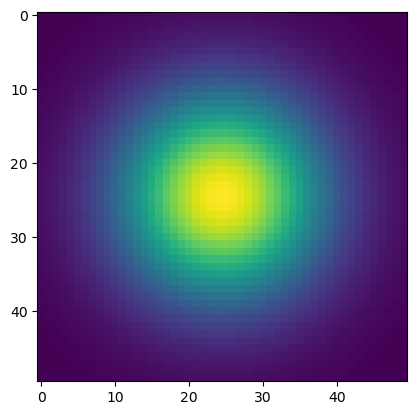

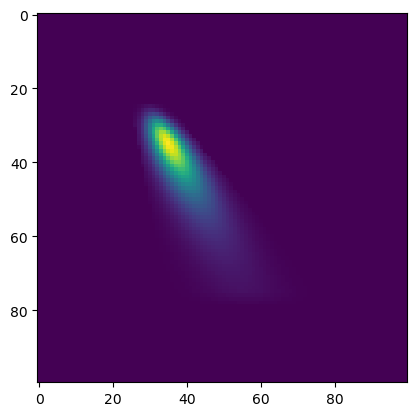

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
width, height = 50,50
canvas = np.zeros((100,100), dtype=np.float32)
gx = np.linspace(-width/2, width/2, width)  # 0から10までを5分割した等差数列を生成   
gy = np.linspace(-height/2, height/2, height)  # 0から10までを5分割した等差数列を生成
gx, gy = np.meshgrid(gx, gy)  # 2次元座標グリッドを生成
sigma_x = max(width/5.0, 1.0)
sigma_y = max(height/5.0, 1.0)
gaussian = np.exp(-((gx**2)/(2*sigma_x**2) + (gy**2)/(2*sigma_y**2))).astype(np.float32)
# ...existing code...
plt.imshow(gaussian)
plt.show()
dst = np.array([
    [0, 0],
    [width-1, 0],
    [width-1, height-1],
    [0, height-1]
], dtype=np.float32)
src = np.array([
    [25, 25],
    [35, 25],
    [75, 75],
    [35, 75]
], dtype=np.float32)

M = cv2.getPerspectiveTransform(dst, src)
warped = cv2.warpPerspective(
    gaussian, M, (canvas.shape[1], canvas.shape[0]),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=0
)
plt.imshow(warped)
plt.show()

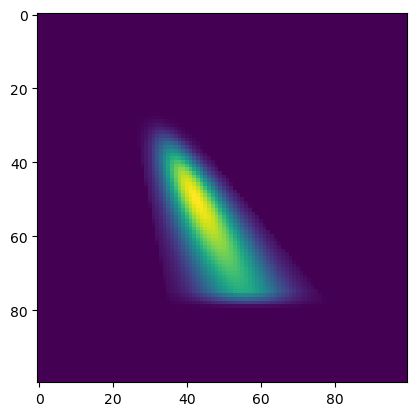

centroid = [42.5 50. ]  long_axis_mid = [42.5 50. ]  peak_target = [42.5 50. ]
rect center mapped = (24.5, 39.2)
調整: alpha を 0~1 で変更してピーク寄せ具合を制御してください。


In [4]:
# 長辺側へピークを意図的に寄せるガウス再生成と可視化
import numpy as np
import cv2
from matplotlib import pyplot as plt

# 1. 長辺ペアの判定（src は 4点: [0,1,2,3]）
# 辺長を計算
edges = [np.linalg.norm(src[i] - src[(i+1)%4]) for i in range(4)]  # (0-1,1-2,2-3,3-0)
# 対向ペア候補: (0-1,2-3) と (1-2,3-0)
sumA = edges[0] + edges[2]
sumB = edges[1] + edges[3]
if sumB > sumA:
    # 1点ローテーションして (1-2,3-0) を (0-1,2-3) 形に合わせる
    src_long_aligned = np.roll(src, -1, axis=0)
else:
    src_long_aligned = src.copy()

# 2. 長辺ペア(0-1 と 2-3) の中点
mid_top = (src_long_aligned[0] + src_long_aligned[1]) / 2.0
mid_bottom = (src_long_aligned[2] + src_long_aligned[3]) / 2.0
# 3. 台形重心（簡易: 4頂点平均で近似。厳密多角形重心でも良い）
centroid = src.mean(axis=0)

# 4. ピーク位置を重心→長辺方向へシフト
#    alpha=0 で重心、alpha=1 で長辺中央線上の mid_top-mid_bottom の中点
long_axis_mid = (mid_top + mid_bottom)/2.0
alpha = 0.6  # 0~1 を調整: 大きいほど長辺側（中央線側）に寄せる
peak_target = (1-alpha)*centroid + alpha*long_axis_mid

# 5. 透視変換行列 (dst->src) と逆行列
M = cv2.getPerspectiveTransform(dst, src)
Minv = np.linalg.inv(M)

# 6. peak_target(台形座標) を矩形座標へ逆写像し、その点をガウス中心に設定
pt = np.array([[[peak_target[0], peak_target[1]]]], dtype=np.float32)
(cx_rect, cy_rect) = cv2.perspectiveTransform(pt, Minv)[0,0]

# 7. バイアス付きガウス生成
xg = np.arange(width, dtype=np.float32)
yg = np.arange(height, dtype=np.float32)
gx2, gy2 = np.meshgrid(xg, yg)
# σ は従来通り。必要なら縦横で補正 (例: 長辺方向 sigma を 1.2倍 等)
# 長辺方向を推定して異方性補正したい場合はベクトル(mid_top-mid_bottom) を利用可能
sigma_x_b = max(width/5.0, 1.0)
sigma_y_b = max(height/5.0, 1.0)
biased_gaussian = np.exp(-(((gx2 - cx_rect)**2)/(2*sigma_x_b**2) + ((gy2 - cy_rect)**2)/(2*sigma_y_b**2))).astype(np.float32)

# 8. ワープして合成（新しいキャンバスを使って比較）
canvas_biased = np.zeros_like(canvas)
warped_biased = cv2.warpPerspective(
    biased_gaussian, M, (canvas_biased.shape[1], canvas_biased.shape[0]),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=0
)
canvas_biased += warped_biased

# 9. 可視化: 元の warped と比較
plt.imshow(canvas_biased, cmap='viridis')
plt.show()

print('centroid =', centroid, ' long_axis_mid =', long_axis_mid, ' peak_target =', peak_target)
print('rect center mapped =', (cx_rect, cy_rect))
print('調整: alpha を 0~1 で変更してピーク寄せ具合を制御してください。')

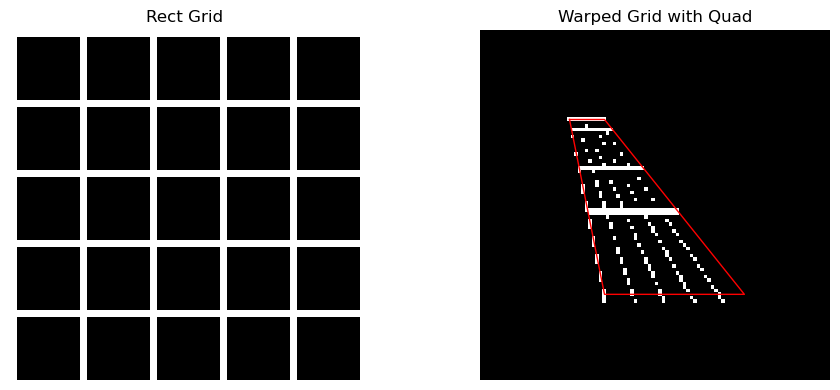

グリッド間隔 step = 10 （値を変えると密度が変わります）


In [9]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

try:
    M
except NameError:
    M = cv2.getPerspectiveTransform(dst, src)

step = 10
grid = np.zeros((height, width), dtype=np.float32)
for y in range(0, height, step):
    grid[y, :] = 1.0
for x in range(0, width, step):
    grid[:, x] = 1.0

# 2) 矩形→台形へ射影
warped_grid = cv2.warpPerspective(
    grid, M, (canvas.shape[1], canvas.shape[0]),
    flags=cv2.INTER_NEAREST,  # 線の鋭さを保つ
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=0
)

# 3) 表示（左:元の矩形グリッド, 右:射影後グリッド＋台形境界）
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Rect Grid')
plt.imshow(grid, cmap='gray', origin='upper')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Warped Grid with Quad')
plt.imshow(warped_grid, cmap='gray', origin='upper')
# 台形境界を赤線で重ね描画
poly = np.vstack([src, src[0]]).astype(np.float32)
plt.plot(poly[:,0], poly[:,1], 'r-', linewidth=1)
plt.axis('off')

plt.tight_layout()
plt.show()

print('グリッド間隔 step =', step, '（値を変えると密度が変わります）')

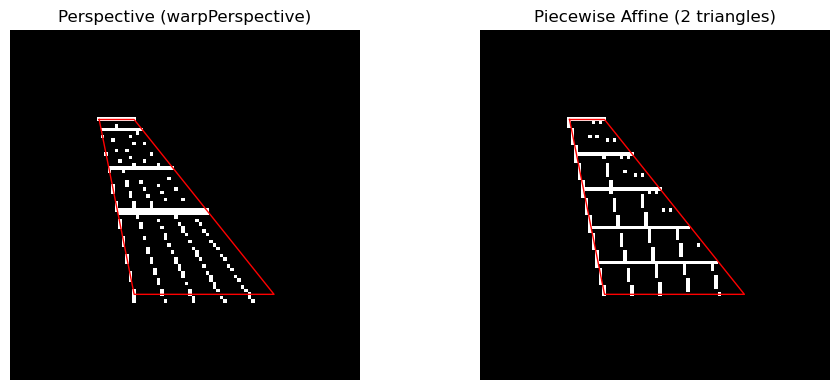

メモ: アフィンは遠近的な縮尺の変化を入れません（各三角形内は線形スケール）。


In [10]:
# ピースワイズ・アフィン（2三角形）でのワープ比較デモ
import numpy as np
import cv2
from matplotlib import pyplot as plt

# 事前に grid, src, dst, width, height, canvas, warped_grid（射影版）がある前提
# ない場合は直前セルを実行してください。

# 三角形ワープのユーティリティ

def warp_triangle(src_img, src_tri, dst_img, dst_tri):
    src_tri = np.float32(src_tri)
    dst_tri = np.float32(dst_tri)

    # 各三角形の外接矩形
    r1 = cv2.boundingRect(src_tri)
    r2 = cv2.boundingRect(dst_tri)

    # 矩形左上へのオフセットを引いた座標
    src_tri_off = np.float32([[src_tri[i][0]-r1[0], src_tri[i][1]-r1[1]] for i in range(3)])
    dst_tri_off = np.float32([[dst_tri[i][0]-r2[0], dst_tri[i][1]-r2[1]] for i in range(3)])

    # ROI 抽出
    src_roi = src_img[r1[1]:r1[1]+r1[3], r1[0]:r1[0]+r1[2]]

    # 三角形マスク
    mask = np.zeros((r2[3], r2[2]), dtype=np.float32)
    cv2.fillConvexPoly(mask, np.int32(dst_tri_off), 1.0)

    # アフィン行列とワープ
    M_aff = cv2.getAffineTransform(src_tri_off, dst_tri_off)
    warped = cv2.warpAffine(src_roi, M_aff, (r2[2], r2[3]), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    # 合成
    dst_sub = dst_img[r2[1]:r2[1]+r2[3], r2[0]:r2[0]+r2[2]]
    dst_sub[:] = dst_sub*(1-mask) + warped*mask

# 元の矩形の対応三角形（長方形→2三角）
rect_tri1 = np.float32([[0,0],[width-1,0],[width-1,height-1]])
rect_tri2 = np.float32([[0,0],[width-1,height-1],[0,height-1]])

# 対応する台形側三角形（src の 4点を [0,1,2,3] として対角分割）
dst_tri1 = np.float32([src[0], src[1], src[2]])
dst_tri2 = np.float32([src[0], src[2], src[3]])

# アフィンでのワープ結果キャンバス
affine_grid = np.zeros_like(canvas)
warp_triangle(grid, rect_tri1, affine_grid, dst_tri1)
warp_triangle(grid, rect_tri2, affine_grid, dst_tri2)

# 可視化（左: 射影, 右: 2三角形アフィン）
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Perspective (warpPerspective)')
plt.imshow(warped_grid, cmap='gray', origin='upper')
poly = np.vstack([src, src[0]]).astype(np.float32)
plt.plot(poly[:,0], poly[:,1], 'r-', linewidth=1)
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Piecewise Affine (2 triangles)')
plt.imshow(affine_grid, cmap='gray', origin='upper')
plt.plot(poly[:,0], poly[:,1], 'r-', linewidth=1)
plt.axis('off')

plt.tight_layout()
plt.show()

print('メモ: アフィンは遠近的な縮尺の変化を入れません（各三角形内は線形スケール）。')

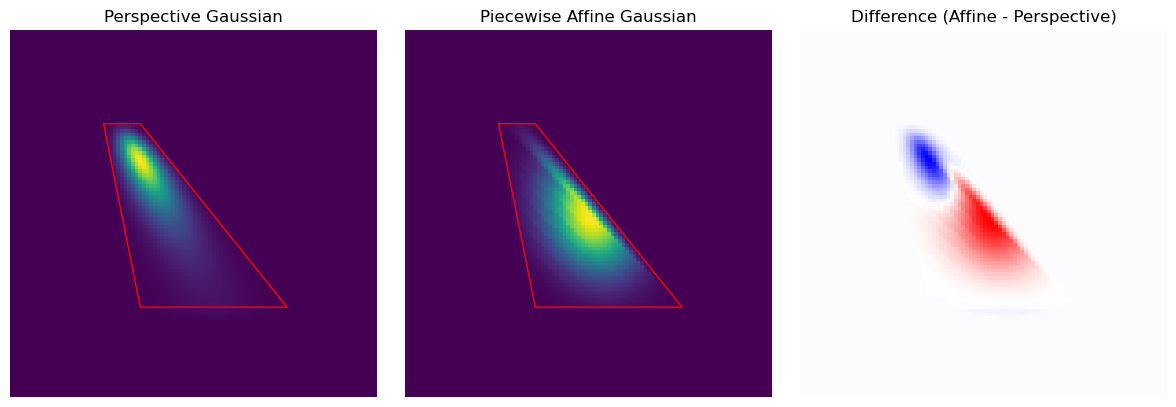

比較メモ: アフィン版は遠近的な伸縮が入らないため、短辺側の“濃さ”偏りが緩和されやすいです。


In [11]:
# Gaussian をピースワイズ・アフィン（2三角形）でワープして比較
import numpy as np
import cv2
from matplotlib import pyplot as plt

# 前セルの gaussian, grid, src, dst, width, height, canvas, M, warped（射影版）を前提
# 用意できていない場合は前のセルを実行してください。

# 三角形ワープ（前セルの関数と同じ。未定義なら再定義）
try:
    warp_triangle
except NameError:
    def warp_triangle(src_img, src_tri, dst_img, dst_tri):
        src_tri = np.float32(src_tri)
        dst_tri = np.float32(dst_tri)
        r1 = cv2.boundingRect(src_tri)
        r2 = cv2.boundingRect(dst_tri)
        src_tri_off = np.float32([[src_tri[i][0]-r1[0], src_tri[i][1]-r1[1]] for i in range(3)])
        dst_tri_off = np.float32([[dst_tri[i][0]-r2[0], dst_tri[i][1]-r2[1]] for i in range(3)])
        src_roi = src_img[r1[1]:r1[1]+r1[3], r1[0]:r1[0]+r1[2]]
        mask = np.zeros((r2[3], r2[2]), dtype=np.float32)
        cv2.fillConvexPoly(mask, np.int32(dst_tri_off), 1.0)
        M_aff = cv2.getAffineTransform(src_tri_off, dst_tri_off)
        warped_local = cv2.warpAffine(src_roi, M_aff, (r2[2], r2[3]), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=0)
        dst_sub = dst_img[r2[1]:r2[1]+r2[3], r2[0]:r2[0]+r2[2]]
        dst_sub[:] = dst_sub*(1-mask) + warped_local*mask

# 矩形側の2三角形
rect_tri1 = np.float32([[0,0],[width-1,0],[width-1,height-1]])
rect_tri2 = np.float32([[0,0],[width-1,height-1],[0,height-1]])
# 台形側の2三角形
dst_tri1 = np.float32([src[0], src[1], src[2]])
dst_tri2 = np.float32([src[0], src[2], src[3]])

# アフィンでガウスをワープ
affine_gaussian = np.zeros_like(canvas)
warp_triangle(gaussian, rect_tri1, affine_gaussian, dst_tri1)
warp_triangle(gaussian, rect_tri2, affine_gaussian, dst_tri2)

# 透視版（既存）
persp_gaussian = cv2.warpPerspective(
    gaussian, M, (canvas.shape[1], canvas.shape[0]),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=0
)

# 可視化: 左=透視, 中=アフィン, 右=差分
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title('Perspective Gaussian')
plt.imshow(persp_gaussian, cmap='viridis', origin='upper')
poly = np.vstack([src, src[0]]).astype(np.float32)
plt.plot(poly[:,0], poly[:,1], 'r-', linewidth=1)
plt.axis('off')

plt.subplot(1,3,2)
plt.title('Piecewise Affine Gaussian')
plt.imshow(affine_gaussian, cmap='viridis', origin='upper')
plt.plot(poly[:,0], poly[:,1], 'r-', linewidth=1)
plt.axis('off')

plt.subplot(1,3,3)
plt.title('Difference (Affine - Perspective)')
plt.imshow(affine_gaussian - persp_gaussian, cmap='bwr', origin='upper')
plt.axis('off')

plt.tight_layout()
plt.show()

print('比較メモ: アフィン版は遠近的な伸縮が入らないため、短辺側の“濃さ”偏りが緩和されやすいです。')

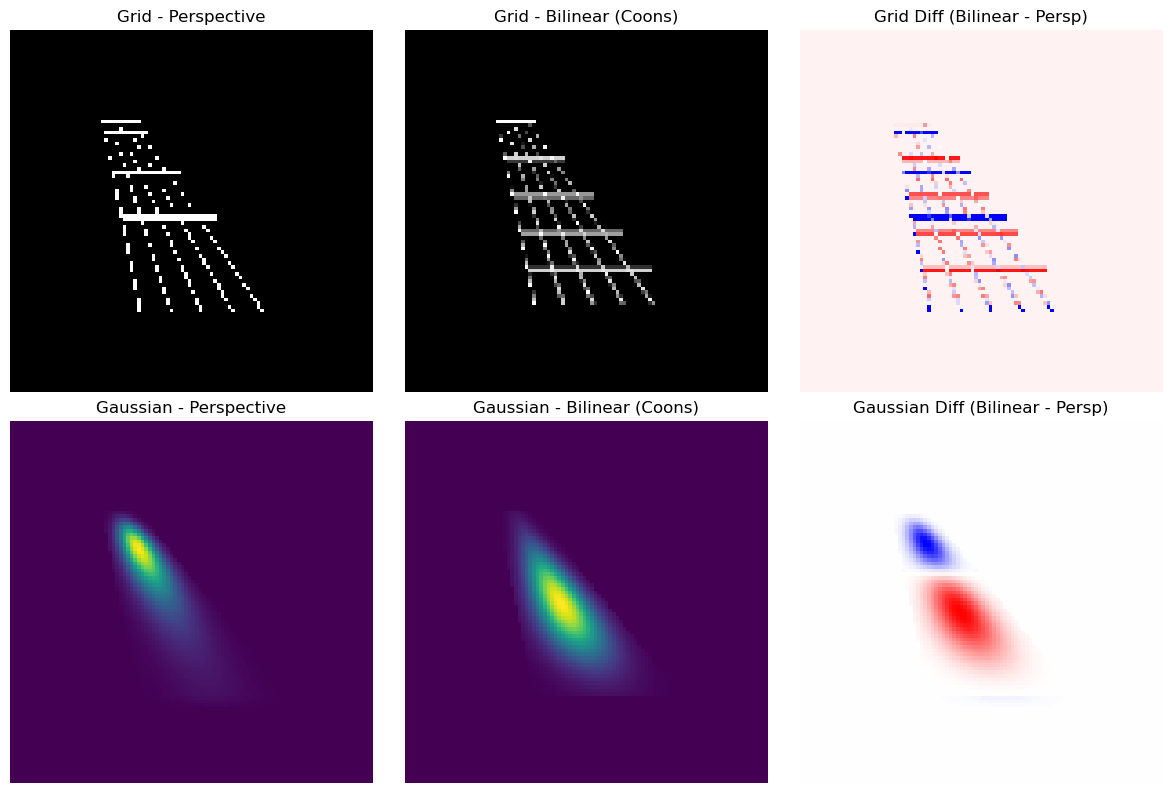

注: バイリニアは連続・無シーム、遠近的な片側の極端な伸縮を抑えます（直線はやや曲がります）。


In [12]:
# 連続な非遠近（バイリニア）四角形ワープ: グリッドとガウスで比較

import numpy as np
import cv2
from matplotlib import pyplot as plt

def warp_quad_bilinear(src_img, quad_xy, out_shape, border_value=0.0, max_iter=10, eps=1e-4):
    """
    src_img: HxW float32
    quad_xy: 4x2 float32, 頂点順は dst=[(0,0),(W-1,0),(W-1,H-1),(0,H-1)] に対応する順（TL,TR,BR,BL）
    out_shape: (out_h, out_w)
    返り値: out_img (out_h x out_w)
    """
    out_h, out_w = out_shape
    out = np.zeros((out_h, out_w), dtype=np.float32)

    # 四角形の頂点（Coonsパッチ）
    Q00, Q10, Q11, Q01 = [quad_xy[i].astype(np.float32) for i in range(4)]
    A = Q00
    B = Q10 - Q00
    C = Q01 - Q00
    D = Q11 - Q10 - Q01 + Q00

    poly = np.array([Q00, Q10, Q11, Q01], dtype=np.float32)
    # 出力→入力（rect座標）マップ
    map_x = np.full((out_h, out_w), -1, dtype=np.float32)
    map_y = np.full((out_h, out_w), -1, dtype=np.float32)

    # 四角形の外接矩形内だけ計算して高速化
    xmin = max(0, int(np.floor(np.min(poly[:,0]))))
    xmax = min(out_w-1, int(np.ceil(np.max(poly[:,0]))))
    ymin = max(0, int(np.floor(np.min(poly[:,1]))))
    ymax = min(out_h-1, int(np.ceil(np.max(poly[:,1]))))

    # 初期ヤコビアン（Dを無視したアフィン近似）
    J0 = np.array([[B[0], C[0]],
                   [B[1], C[1]]], dtype=np.float32)
    detJ0 = float(J0[0,0]*J0[1,1] - J0[0,1]*J0[1,0])
    if abs(detJ0) < 1e-6:
        # 退化対策
        J0 += 1e-6*np.eye(2, dtype=np.float32)

    for y in range(ymin, ymax+1):
        for x in range(xmin, xmax+1):
            # 四角形内かチェック
            if cv2.pointPolygonTest(poly, (float(x), float(y)), False) < 0:
                continue

            P = np.array([x, y], dtype=np.float32)
            rhs = P - A
            # 初期値: アフィン近似で解く
            u0 = ( rhs[0]*J0[1,1] - rhs[1]*J0[0,1]) / detJ0
            v0 = (-rhs[0]*J0[1,0] + rhs[1]*J0[0,0]) / detJ0
            u, v = float(u0), float(v0)

            # Newton-Raphson
            for _ in range(max_iter):
                F = A + B*u + C*v + D*(u*v) - P
                if F.dot(F) < eps*eps:
                    break
                # ヤコビアン J(u,v) = [B + D*v, C + D*u]
                Ju = B + D*v
                Jv = C + D*u
                J = np.array([[Ju[0], Jv[0]],
                              [Ju[1], Jv[1]]], dtype=np.float32)
                detJ = float(J[0,0]*J[1,1] - J[0,1]*J[1,0])
                if abs(detJ) < 1e-8:
                    break
                # 解く: J * delta = -F
                delta_u = ( -F[0]*J[1,1] + F[1]*J[0,1]) / detJ
                delta_v = (  F[0]*J[1,0] - F[1]*J[0,0]) / detJ
                u += float(delta_u)
                v += float(delta_v)

            # [0,1]にクリップ
            u = min(max(u, 0.0), 1.0)
            v = min(max(v, 0.0), 1.0)

            # 矩形内のサンプリング座標に変換（src_img は (height,width)）
            src_h, src_w = src_img.shape[:2]
            map_x[y, x] = u * (src_w - 1)
            map_y[y, x] = v * (src_h - 1)

    out = cv2.remap(src_img, map_x, map_y, interpolation=cv2.INTER_LINEAR,
                    borderMode=cv2.BORDER_CONSTANT, borderValue=border_value)
    return out

# 既存の M, src(台形座標), grid, gaussian, canvas を利用
try:
    _ = src.shape
except NameError:
    raise RuntimeError("先に src/dst/M を作るセルを実行してください。")

# 1) グリッド: 透視 vs バイリニア
bilinear_grid = warp_quad_bilinear(grid, src, canvas.shape, border_value=0.0)
persp_grid = warped_grid  # 既存

# 2) ガウス: 透視 vs バイリニア
persp_gaussian = cv2.warpPerspective(
    gaussian, M, (canvas.shape[1], canvas.shape[0]),
    flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=0
)
bilinear_gaussian = warp_quad_bilinear(gaussian, src, canvas.shape, border_value=0.0)

# 可視化
plt.figure(figsize=(12,8))

plt.subplot(2,3,1); plt.title('Grid - Perspective')
plt.imshow(persp_grid, cmap='gray', origin='upper'); plt.axis('off')

plt.subplot(2,3,2); plt.title('Grid - Bilinear (Coons)')
plt.imshow(bilinear_grid, cmap='gray', origin='upper'); plt.axis('off')

plt.subplot(2,3,3); plt.title('Grid Diff (Bilinear - Persp)')
plt.imshow(bilinear_grid - persp_grid, cmap='bwr', origin='upper'); plt.axis('off')

plt.subplot(2,3,4); plt.title('Gaussian - Perspective')
plt.imshow(persp_gaussian, cmap='viridis', origin='upper'); plt.axis('off')

plt.subplot(2,3,5); plt.title('Gaussian - Bilinear (Coons)')
plt.imshow(bilinear_gaussian, cmap='viridis', origin='upper'); plt.axis('off')

plt.subplot(2,3,6); plt.title('Gaussian Diff (Bilinear - Persp)')
plt.imshow(bilinear_gaussian - persp_gaussian, cmap='bwr', origin='upper'); plt.axis('off')

plt.tight_layout()
plt.show()

print('注: バイリニアは連続・無シーム、遠近的な片側の極端な伸縮を抑えます（直線はやや曲がります）。')